# AGUACATE Y LIMÓN: Predicción de precios para una comercialización justa

## Análisis de series de tiempo en mercados clave de México

**Michoacán, Veracruz y el Valle de México concentran la mayor producción nacional de aguacate Hass y limón Persa, dos productos emblemáticos que sostienen la economía agrícola de estas regiones y forman parte esencial de la canasta básica mexicana.** México es líder mundial en aguacate (2.5 millones de toneladas anuales) y figura entre los principales exportadores de limón, generando empleo directo e indirecto para miles de familias rurales y fortaleciendo el tejido social mediante cooperativas productoras.

**Sin embargo, esta importancia económica convive con una marcada volatilidad de precios que genera incertidumbre para pequeños productores.** En los últimos años, el precio del aguacate ha oscilado entre $28 y $110 pesos por kg, mientras que el limón presenta picos estacionales que pueden cuadruplicar su valor en semanas. Estas fluctuaciones, determinadas por factores estacionales, climáticos, fitosanitarios y la intervención de intermediarios, dificultan decisiones críticas como el momento óptimo de venta, el uso eficiente de capacidad de almacenamiento y la participación en programas de precio de garantía.

**El presente proyecto responde a esta problemática mediante el desarrollo de modelos de series de tiempo que pronostiquen precios mensuales de aguacate y limón en mercados estratégicos del Valle de México (Central de Abastos CDMX), Michoacán (Morelia) y Veracruz.** El análisis sistematiza datos oficiales del SNIIM y FIRA, implementando técnicas estadísticas y de machine learning (ARIMA/SARIMA, Prophet, suavizamiento exponencial, LSTM) para generar recomendaciones accionables que optimicen la comercialización, reduzcan la volatilidad de ingresos y promuevan prácticas de mercado más equitativas.

**El notebook se estructura en ocho secciones que abordan desde el contexto socioeconómico hasta la reflexión ética sobre el acceso a herramientas predictivas, siguiendo la metodología del Problema Prototípico "Mercado Justo".**

---
**Datos**: SNIIM (2016-2026) | **Mercados**: CDMX, Morelia, Veracruz

# Regresion Polinomial
La regresion polinomial es una extensión de la regresión lineal que permite modelar relaciones no lineales entre las variables independientes y la variable dependiente. En este caso, se busca predecir el precio del aguacate o limón en función del tiempo (mes y año) utilizando un modelo de regresión polinomial. Para esto, se transforman las variables predictoras (mes y año) en términos polinomiales, lo que permite capturar patrones más complejos en los datos. El modelo se entrena utilizando los precios históricos de aguacate y limón, y luego se evalúa su rendimiento mediante métricas como el R^2. Finalmente, se visualizan los resultados mediante gráficos que muestran la relación entre el tiempo y el precio, junto con la curva ajustada por el modelo polinomial.

In [36]:
import pandas as pd
import numpy as np
import re


def preparar_mensual(
    df_base,
    producto=None,
    presentacion=None,
    origen=None,
    destino=None,
    normalizar_por_kg=False,
):
    """Convierte datos diarios a promedio mensual para un filtro dado."""
    df_tmp = df_base.copy()
    df_tmp['fecha'] = pd.to_datetime(df_tmp['fecha'], format='%d/%m/%Y', errors='coerce')
    df_tmp['precio_frec'] = pd.to_numeric(
        df_tmp['precio_frec'].astype(str).str.replace(',', ''),
        errors='coerce'
    )

    if producto is not None:
        df_tmp = df_tmp[df_tmp['producto'] == producto]
    if presentacion is not None:
        df_tmp = df_tmp[df_tmp['presentacion'] == presentacion]
    if origen is not None:
        df_tmp = df_tmp[df_tmp['origen'].astype(str).str.contains(origen, case=False, na=False)]
    if destino is not None:
        df_tmp = df_tmp[df_tmp['destino'].astype(str).str.contains(destino, case=False, na=False)]

    if normalizar_por_kg:
        def extraer_kg(texto):
            if pd.isna(texto):
                return np.nan
            texto = str(texto)
            if 'Kilogramo' in texto:
                return 1.0
            match = re.search(r'(\d+(?:\.\d+)?)\s*kg', texto, flags=re.IGNORECASE)
            return float(match.group(1)) if match else np.nan

        df_tmp['kg_presentacion'] = df_tmp['presentacion'].apply(extraer_kg)
        df_tmp['precio_modelo'] = df_tmp['precio_frec'] / df_tmp['kg_presentacion']
    else:
        df_tmp['precio_modelo'] = df_tmp['precio_frec']

    df_tmp = df_tmp.dropna(subset=['fecha', 'precio_modelo']).copy()
    df_tmp['anio'] = df_tmp['fecha'].dt.year
    df_tmp['mes'] = df_tmp['fecha'].dt.month

    df_monthly = df_tmp.groupby(['anio', 'mes'], as_index=False)['precio_modelo'].mean()
    df_monthly = df_monthly.sort_values(['anio', 'mes']).reset_index(drop=True)
    df_monthly['fecha'] = pd.to_datetime({
        'year': df_monthly['anio'],
        'month': df_monthly['mes'],
        'day': 1
    })
    df_monthly = df_monthly.rename(columns={'precio_modelo': 'precio_mensual'})
    return df_monthly


# Datos base para todos los ejemplos (origen diario)
df_base = pd.read_csv("sniim_resultados.csv")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

### Aguacate Hass - Primera

Gráfica guardada como 'regresion_polinomial_resultado.png'


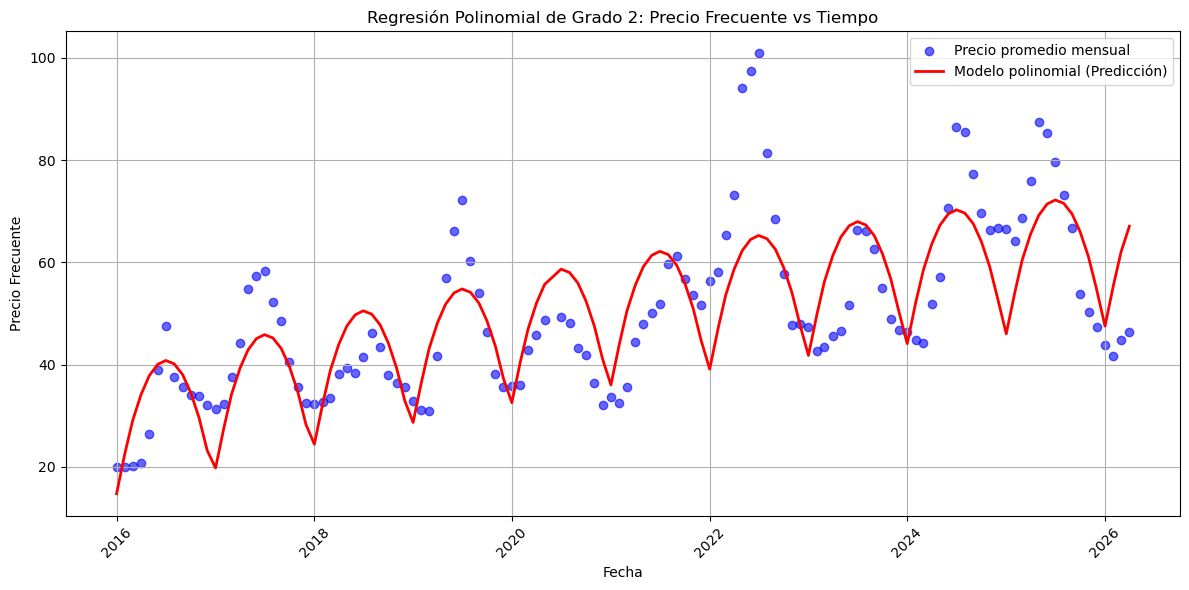

Score del modelo (R^2): 0.5934


In [37]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Leer y agregar a precio mensual desde datos diarios
df_monthly = preparar_mensual(
    df_base,
    producto='Aguacate Hass - Primera',
    presentacion='Kilogramo',
)

# 3. Preparar X e y
X = df_monthly[['mes', 'anio']].values
y = df_monthly['precio_mensual'].values

# 4. Regresión Polinomial
grado = 2
poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# 5. Crear columna de fecha para graficar
# FIX 2: pd.to_datetime necesita columnas nombradas 'year', 'month', 'day' (en inglés)
df_monthly['fecha'] = pd.to_datetime({
    'year': df_monthly['anio'],
    'month': df_monthly['mes'],
    'day': 1
})
df_monthly = df_monthly.sort_values('fecha')

X_sorted = df_monthly[['mes', 'anio']].values
y_sorted = df_monthly['precio_mensual'].values
y_pred_sorted = model.predict(poly.transform(X_sorted))

# 6. Visualización
plt.figure(figsize=(12, 6))

plt.scatter(df_monthly['fecha'], y_sorted, color='blue', alpha=0.6, label='Precio promedio mensual')
plt.plot(df_monthly['fecha'], y_pred_sorted, color='red', linewidth=2, label='Modelo polinomial (Predicción)')

plt.title(f'Regresión Polinomial de Grado {grado}: Precio Frecuente vs Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio Frecuente')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('regresion_polinomial_resultado.png')
print("Gráfica guardada como 'regresion_polinomial_resultado.png'")
plt.show()

print(f"Score del modelo (R^2): {model.score(X_poly, y):.4f}")


### Limón s/semilla - Primera

Gráfica guardada como 'regresion_polinomial_resultado.png'


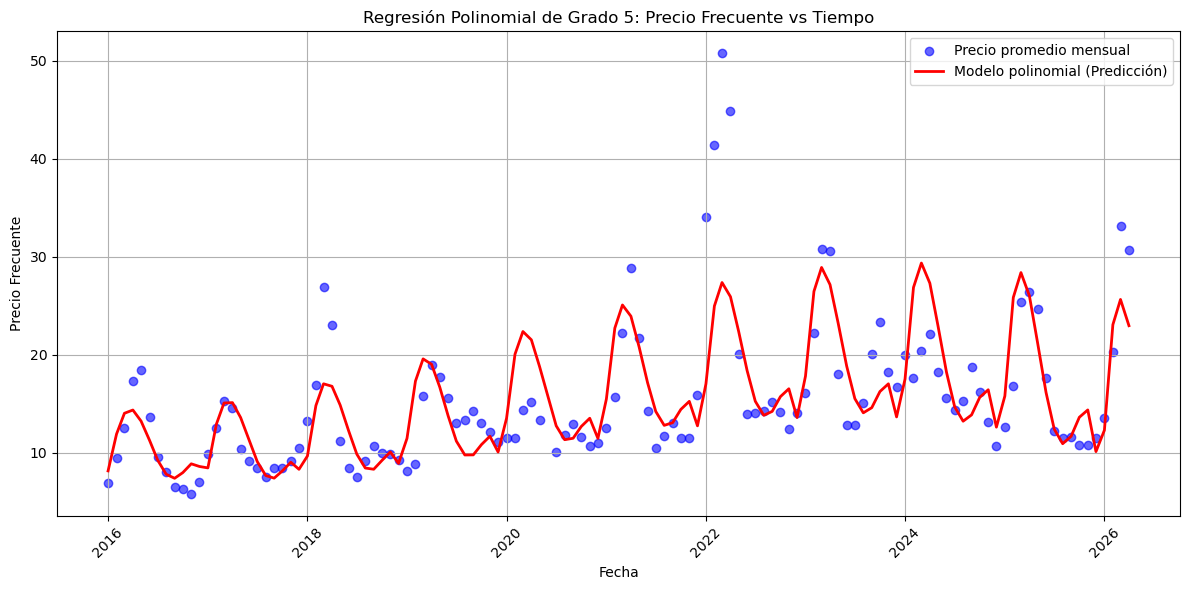

Score del modelo (R^2): 0.5642


In [38]:
# 1. Leer y agregar a precio mensual desde datos diarios
df_monthly = preparar_mensual(
    df_base,
    producto='Limón s/semilla - Primera',
    presentacion='Kilogramo',
)

# 3. Preparar X e y
X = df_monthly[['mes', 'anio']].values
y = df_monthly['precio_mensual'].values

# 4. Regresión Polinomial
grado = 5
poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# 5. Crear columna de fecha para graficar
# FIX 2: pd.to_datetime necesita columnas nombradas 'year', 'month', 'day' (en inglés)
df_monthly['fecha'] = pd.to_datetime({
    'year': df_monthly['anio'],
    'month': df_monthly['mes'],
    'day': 1
})
df_monthly = df_monthly.sort_values('fecha')

X_sorted = df_monthly[['mes', 'anio']].values
y_sorted = df_monthly['precio_mensual'].values
y_pred_sorted = model.predict(poly.transform(X_sorted))

# 6. Visualización
plt.figure(figsize=(12, 6))

plt.scatter(df_monthly['fecha'], y_sorted, color='blue', alpha=0.6, label='Precio promedio mensual')
plt.plot(df_monthly['fecha'], y_pred_sorted, color='red', linewidth=2, label='Modelo polinomial (Predicción)')

plt.title(f'Regresión Polinomial de Grado {grado}: Precio Frecuente vs Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio Frecuente')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('regresion_polinomial_resultado.png')
print("Gráfica guardada como 'regresion_polinomial_resultado.png'")
plt.show()

print(f"Score del modelo (R^2): {model.score(X_poly, y):.4f}")


### Limón c/semilla - Primera

Gráfica guardada como 'regresion_polinomial_resultado.png'


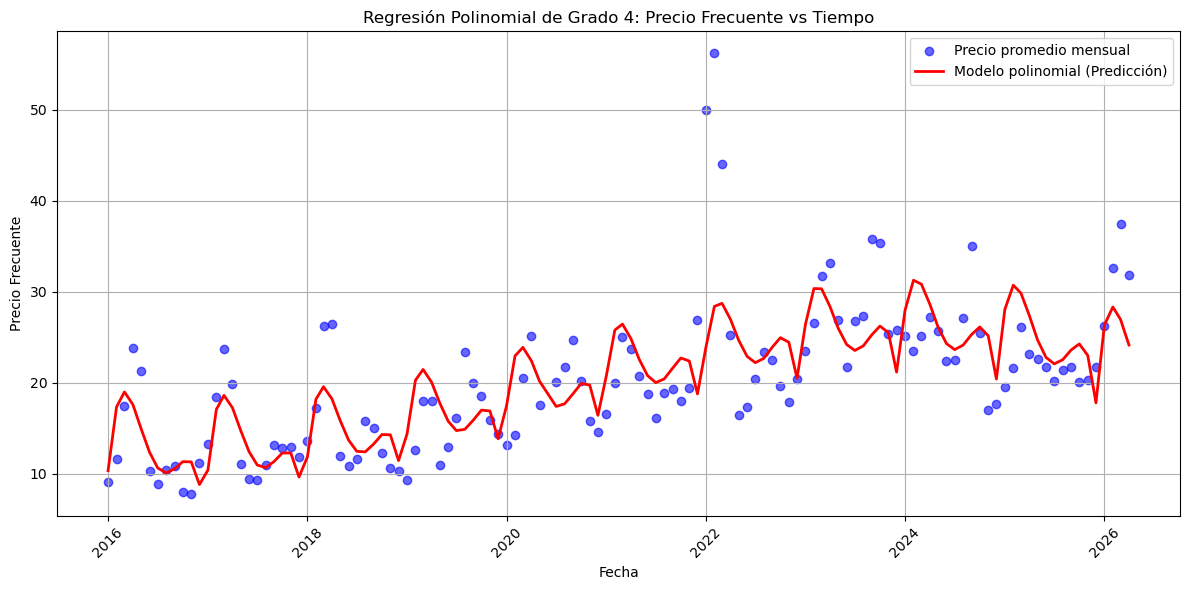

Score del modelo (R^2): 0.5168


In [39]:
# 1. Leer y agregar a precio mensual desde datos diarios
df_monthly = preparar_mensual(
    df_base,
    producto='Limón c/semilla # 5 - Primera',
    presentacion='Kilogramo',
)

# 3. Preparar X e y
X = df_monthly[['mes', 'anio']].values
y = df_monthly['precio_mensual'].values

# 4. Regresión Polinomial
grado = 4
poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# 5. Crear columna de fecha para graficar
# FIX 2: pd.to_datetime necesita columnas nombradas 'year', 'month', 'day' (en inglés)
df_monthly['fecha'] = pd.to_datetime({
    'year': df_monthly['anio'],
    'month': df_monthly['mes'],
    'day': 1
})
df_monthly = df_monthly.sort_values('fecha')

X_sorted = df_monthly[['mes', 'anio']].values
y_sorted = df_monthly['precio_mensual'].values
y_pred_sorted = model.predict(poly.transform(X_sorted))

# 6. Visualización
plt.figure(figsize=(12, 6))

plt.scatter(df_monthly['fecha'], y_sorted, color='blue', alpha=0.6, label='Precio promedio mensual')
plt.plot(df_monthly['fecha'], y_pred_sorted, color='red', linewidth=2, label='Modelo polinomial (Predicción)')

plt.title(f'Regresión Polinomial de Grado {grado}: Precio Frecuente vs Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio Frecuente')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('regresion_polinomial_resultado.png')
print("Gráfica guardada como 'regresion_polinomial_resultado.png'")
plt.show()

print(f"Score del modelo (R^2): {model.score(X_poly, y):.4f}")


## Regresion Logistica
En este caso, se busca predecir si el precio del aguacate o limón será alto o bajo, utilizando un modelo de regresión logística. Para esto, se define un umbral de precio que clasifica los precios como "alto" o "bajo". Por ejemplo, si el precio del aguacate es mayor o igual a $50 pesos por kg, se considera "alto", y si es menor, se considera "bajo". De manera similar, para el limón, se puede definir un umbral de $30 pesos por kg. El modelo de regresión logística se entrenará utilizando las mismas variables predictoras (mes y año) para predecir la probabilidad de que el precio sea alto o bajo. Luego, se evaluará el rendimiento del modelo utilizando métricas como la precisión, el recall, la F1-score y el AUC-ROC, y se analizará cómo varían estas métricas al ajustar el umbral de clasificación. Además, se pueden generar gráficos de la curva ROC y la curva de precisión-recall para visualizar el desempeño del modelo en diferentes umbrales. Este análisis permitirá entender mejor la capacidad del modelo para distinguir entre precios altos y bajos, y cómo se pueden ajustar los umbrales para optimizar la toma de decisiones en la comercialización de aguacate y limón.

Observaciones mensuales: 122
Umbral usado: 50.00 MXN/kg
   anio  mes  precio_mensual  precio_alto
0  2016    1       16.000000            0
1  2016    2       18.650000            0
2  2016    3       18.400000            0
3  2016    4       19.809524            0
4  2016    5       29.571429            0

Metricas de clasificacion:
Accuracy : 0.4839
Precision: 0.5000
Recall   : 0.7500
F1-score : 0.6000
ROC-AUC  : 0.4667

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.43      0.20      0.27        15
           1       0.50      0.75      0.60        16

    accuracy                           0.48        31
   macro avg       0.46      0.47      0.44        31
weighted avg       0.47      0.48      0.44        31



<Figure size 500x400 with 0 Axes>

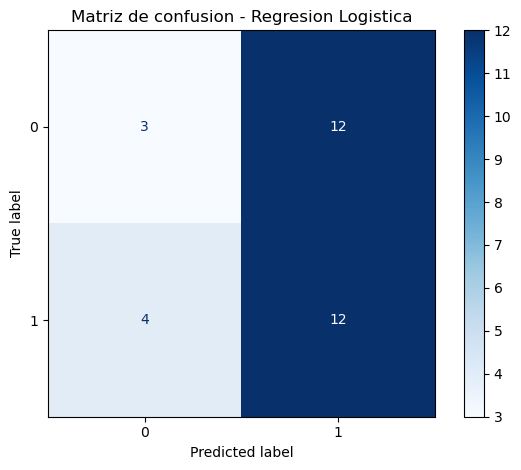

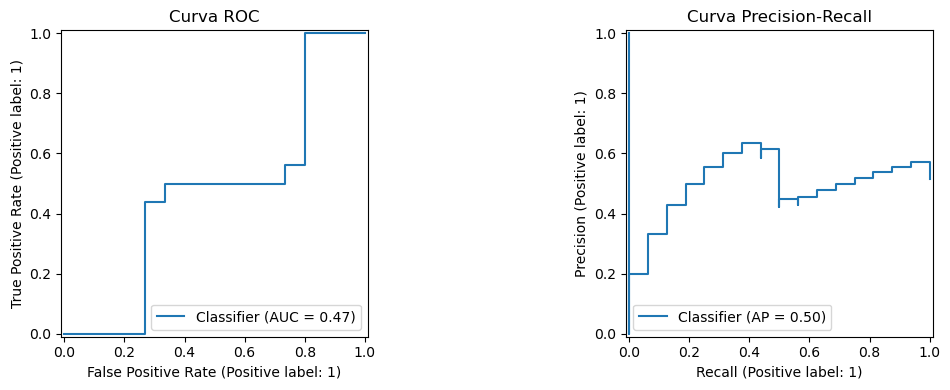

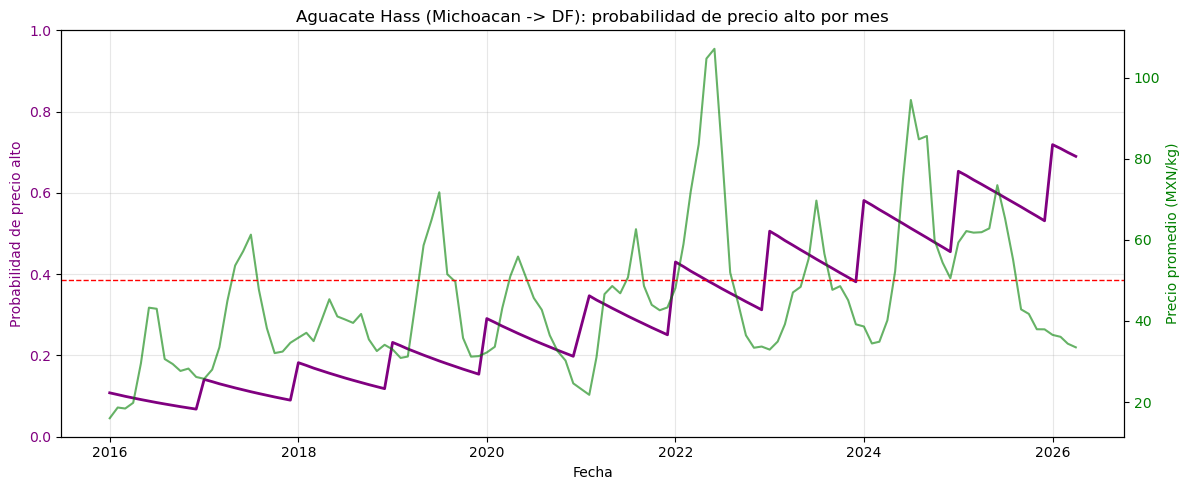

In [40]:
# 1. Leer y agregar a precio mensual desde datos diarios
df_monthly = preparar_mensual(
    df_base,
    producto='Aguacate Hass - Primera',
    presentacion=None,
    origen='Micho',
    destino='Iztapalapa DF',
    normalizar_por_kg=True,
)

# 6. Etiqueta binaria: precio alto (>= 50 MXN/kg)
umbral_precio = 50.0
df_monthly['precio_alto'] = (df_monthly['precio_mensual'] >= umbral_precio).astype(int)

# Si el umbral no genera dos clases, usar mediana para mantener un problema clasificable
if df_monthly['precio_alto'].nunique() < 2:
    umbral_precio = float(df_monthly['precio_mensual'].median())
    df_monthly['precio_alto'] = (df_monthly['precio_mensual'] >= umbral_precio).astype(int)

print(f"Observaciones mensuales: {len(df_monthly)}")
print(f"Umbral usado: {umbral_precio:.2f} MXN/kg")
print(df_monthly[['anio', 'mes', 'precio_mensual', 'precio_alto']].head())

# 7. Entrenamiento (split temporal)
X = df_monthly[['mes', 'anio']]
y = df_monthly['precio_alto']

if len(df_monthly) < 12:
    raise ValueError("Muy pocos datos mensuales para entrenar y evaluar de forma robusta.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)

# 8. Predicciones y métricas
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nMetricas de clasificacion:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, zero_division=0):.4f}")

if y_test.nunique() > 1:
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
else:
    print("ROC-AUC  : No disponible (solo una clase en y_test)")

print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, zero_division=0))

# 9. Visualizaciones de desempeño
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Matriz de confusion - Regresion Logistica')
plt.tight_layout()
plt.show()

if y_test.nunique() > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
    axes[0].set_title('Curva ROC')

    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1])
    axes[1].set_title('Curva Precision-Recall')

    plt.tight_layout()
    plt.show()

# 10. Probabilidad estimada de precio alto sobre toda la serie mensual
df_monthly['prob_precio_alto'] = model.predict_proba(X)[:, 1]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_monthly['fecha'], df_monthly['prob_precio_alto'], color='purple', linewidth=2)
ax1.set_ylabel('Probabilidad de precio alto', color='purple')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_monthly['fecha'], df_monthly['precio_mensual'], color='green', alpha=0.6)
ax2.axhline(umbral_precio, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Precio promedio (MXN/kg)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Aguacate Hass (Michoacan -> DF): probabilidad de precio alto por mes')
ax1.set_xlabel('Fecha')
plt.tight_layout()
plt.show()


### Arboles de decision


Producto: Aguacate Hass - Primera
Criterio: gini | Umbral usado: 50.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.6774
Precision: 1.0000
Recall   : 0.5238
F1-score : 0.6875
ROC-AUC  : 0.7619

Matriz de confusion:
[[10  0]
 [10 11]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        10
           1       1.00      0.52      0.69        21

    accuracy                           0.68        31
   macro avg       0.75      0.76      0.68        31
weighted avg       0.84      0.68      0.68        31

Reglas del arbol:
|--- anio <= 2020.50
|   |--- mes <= 4.50
|   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- mes <= 8.50
|   |   |   |--- class: 0
|   |   |--- mes >  8.50
|   |   |   |--- class: 0
|--- anio >  2020.50
|   |--- mes <= 5.50
|   |   |--- anio <= 2021.50
|   |   |   |--- class: 0
|   |   |--- anio >  2021.50
|   |   |   |--- class: 0
|   |--- mes >  5.50
|   |   |--- mes <= 10.50
|   |  

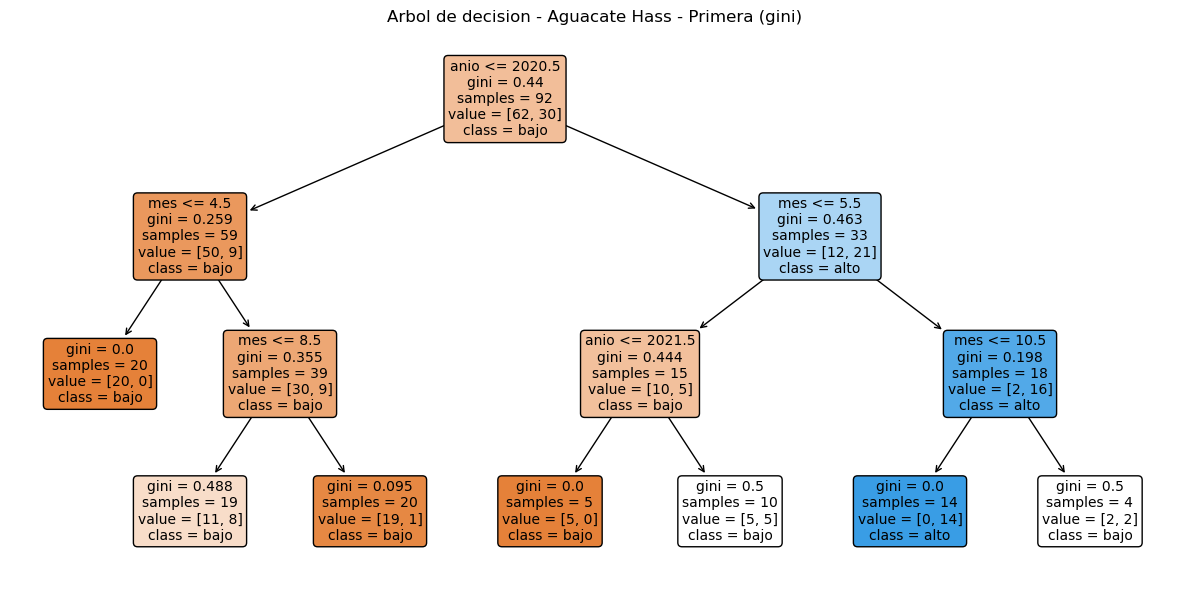


Producto: Aguacate Hass - Primera
Criterio: entropy | Umbral usado: 50.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.6774
Precision: 1.0000
Recall   : 0.5238
F1-score : 0.6875
ROC-AUC  : 0.7619

Matriz de confusion:
[[10  0]
 [10 11]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        10
           1       1.00      0.52      0.69        21

    accuracy                           0.68        31
   macro avg       0.75      0.76      0.68        31
weighted avg       0.84      0.68      0.68        31

Reglas del arbol:
|--- anio <= 2020.50
|   |--- mes <= 4.50
|   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- mes <= 9.50
|   |   |   |--- class: 0
|   |   |--- mes >  9.50
|   |   |   |--- class: 0
|--- anio >  2020.50
|   |--- mes <= 5.50
|   |   |--- anio <= 2021.50
|   |   |   |--- class: 0
|   |   |--- anio >  2021.50
|   |   |   |--- class: 0
|   |--- mes >  5.50
|   |   |--- mes <= 10.50
|   

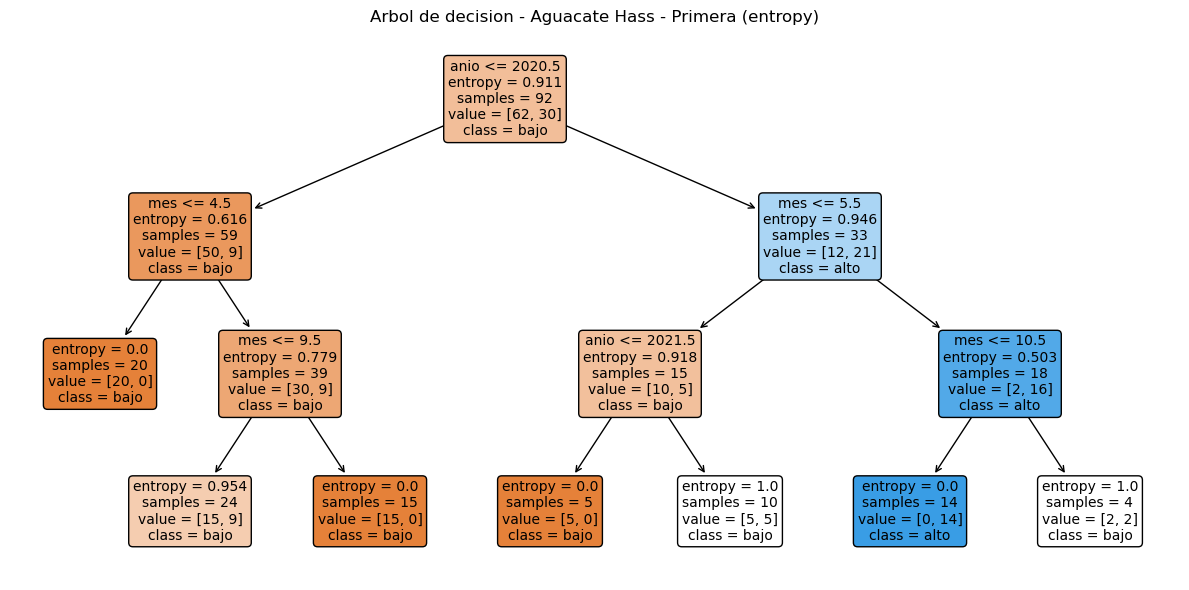


Producto: Limón s/semilla - Primera
Criterio: gini | Umbral usado: 30.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.9355
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.8276

Matriz de confusion:
[[29  0]
 [ 2  0]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        29
           1       0.00      0.00      0.00         2

    accuracy                           0.94        31
   macro avg       0.47      0.50      0.48        31
weighted avg       0.88      0.94      0.90        31

Reglas del arbol:
|--- anio <= 2021.50
|   |--- class: 0
|--- anio >  2021.50
|   |--- mes <= 4.50
|   |   |--- anio <= 2022.50
|   |   |   |--- class: 1
|   |   |--- anio >  2022.50
|   |   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- class: 0



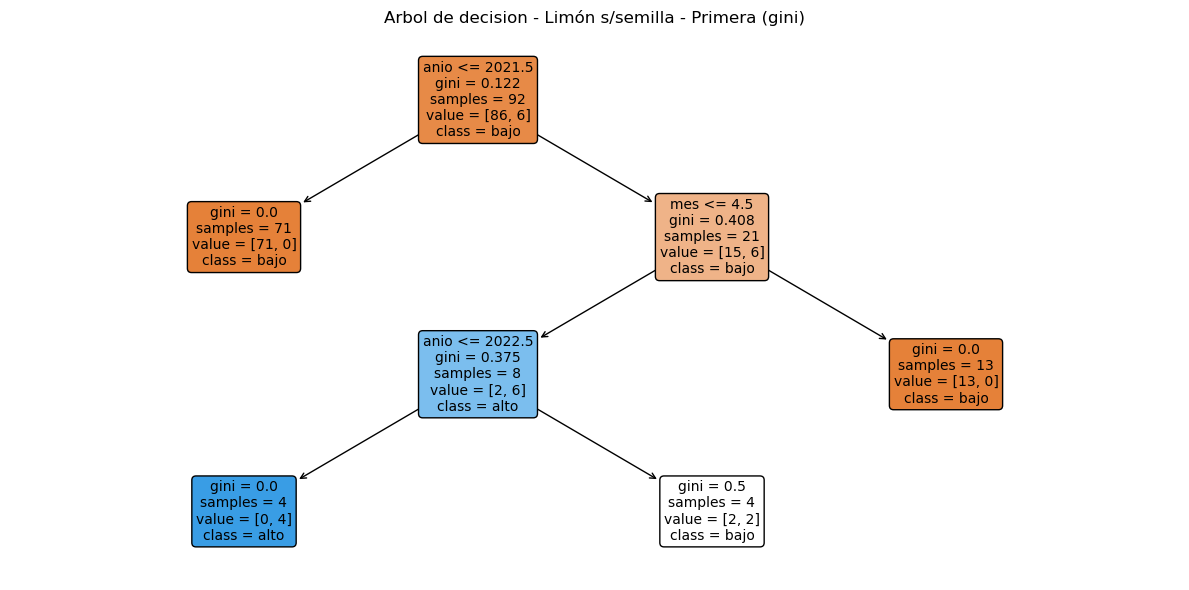


Producto: Limón s/semilla - Primera
Criterio: entropy | Umbral usado: 30.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.9355
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.8276

Matriz de confusion:
[[29  0]
 [ 2  0]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        29
           1       0.00      0.00      0.00         2

    accuracy                           0.94        31
   macro avg       0.47      0.50      0.48        31
weighted avg       0.88      0.94      0.90        31

Reglas del arbol:
|--- anio <= 2021.50
|   |--- class: 0
|--- anio >  2021.50
|   |--- mes <= 4.50
|   |   |--- anio <= 2022.50
|   |   |   |--- class: 1
|   |   |--- anio >  2022.50
|   |   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- class: 0



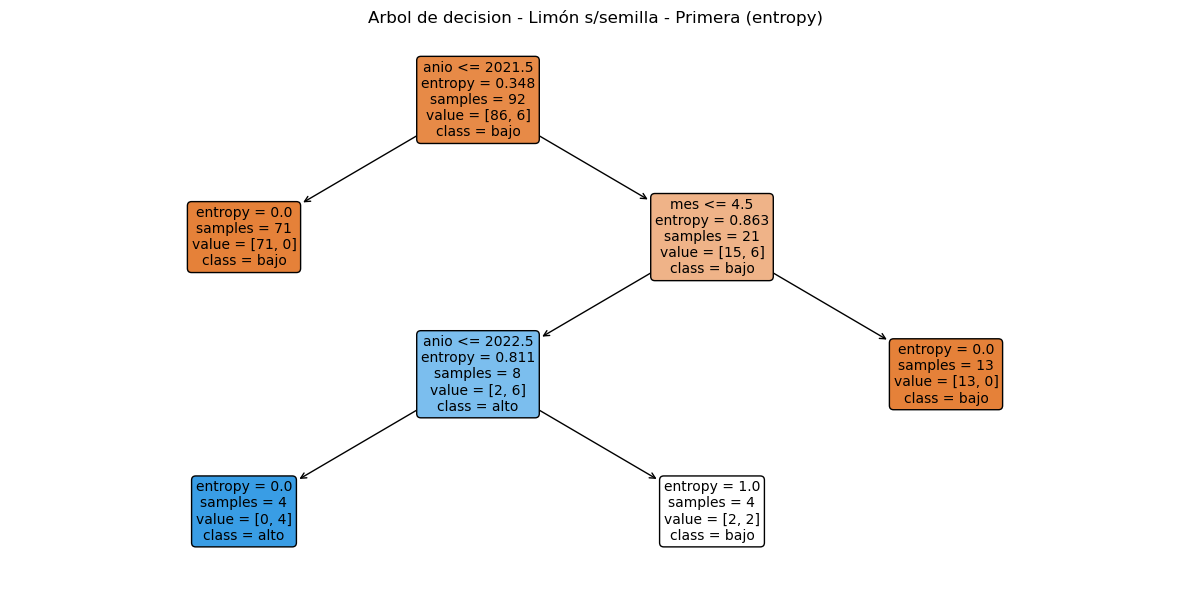


Producto: Limón c/semilla # 5 - Primera
Criterio: gini | Umbral usado: 30.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.8387
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.6885

Matriz de confusion:
[[26  0]
 [ 5  0]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        26
           1       0.00      0.00      0.00         5

    accuracy                           0.84        31
   macro avg       0.42      0.50      0.46        31
weighted avg       0.70      0.84      0.77        31

Reglas del arbol:
|--- anio <= 2021.50
|   |--- class: 0
|--- anio >  2021.50
|   |--- mes <= 4.50
|   |   |--- anio <= 2022.50
|   |   |   |--- class: 1
|   |   |--- anio >  2022.50
|   |   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- mes <= 8.50
|   |   |   |--- class: 0
|   |   |--- mes >  8.50
|   |   |   |--- class: 0



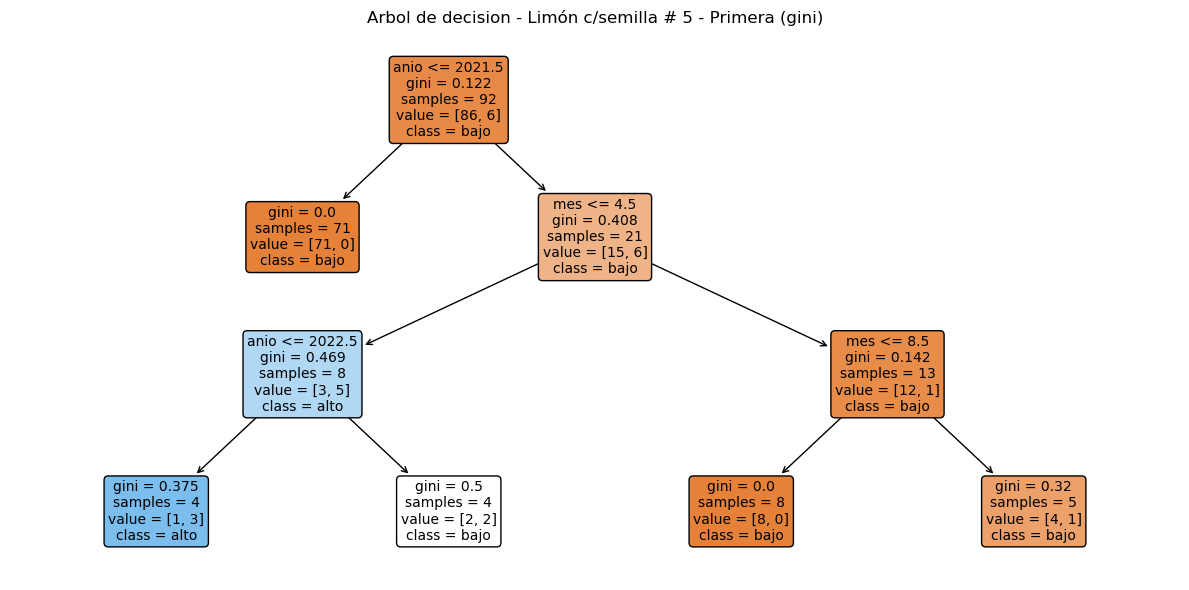


Producto: Limón c/semilla # 5 - Primera
Criterio: entropy | Umbral usado: 30.00 MXN/kg
Registros mensuales: 123
Accuracy : 0.8387
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.6885

Matriz de confusion:
[[26  0]
 [ 5  0]]

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        26
           1       0.00      0.00      0.00         5

    accuracy                           0.84        31
   macro avg       0.42      0.50      0.46        31
weighted avg       0.70      0.84      0.77        31

Reglas del arbol:
|--- anio <= 2021.50
|   |--- class: 0
|--- anio >  2021.50
|   |--- mes <= 4.50
|   |   |--- anio <= 2022.50
|   |   |   |--- class: 1
|   |   |--- anio >  2022.50
|   |   |   |--- class: 0
|   |--- mes >  4.50
|   |   |--- mes <= 8.50
|   |   |   |--- class: 0
|   |   |--- mes >  8.50
|   |   |   |--- class: 0



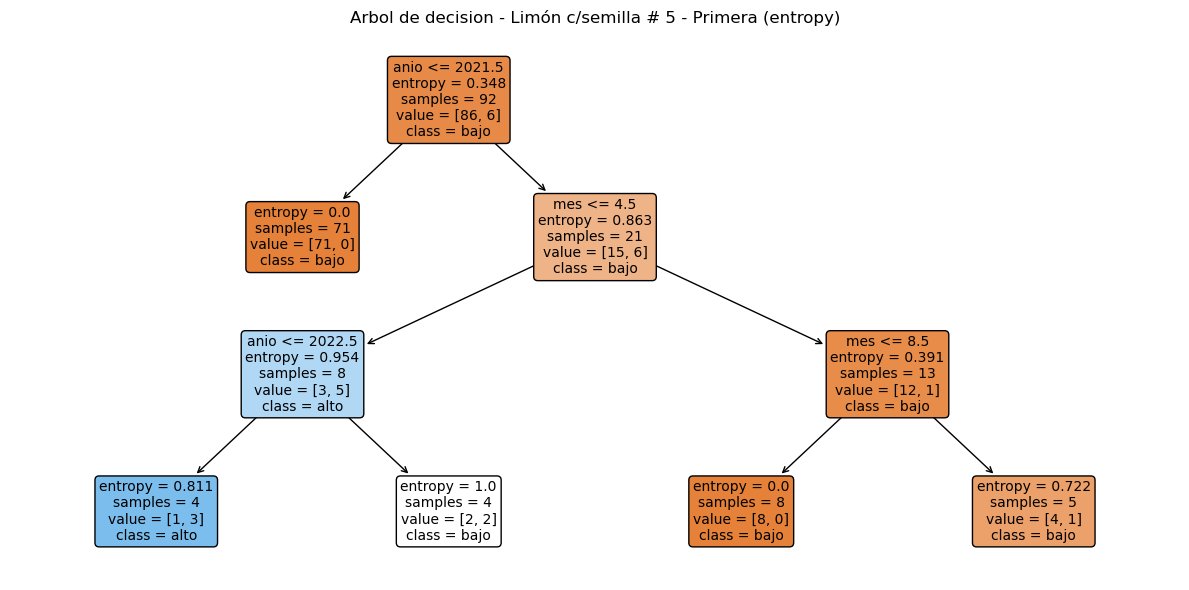


Nuevos periodos para prediccion:
   mes  anio
0    1  2027
1    3  2027
2    6  2027
3    9  2027
4   12  2027

Prediccion (Aguacate Hass - Primera - gini):
[0 0 1 1 0]

Prediccion (Aguacate Hass - Primera - entropy):
[0 0 1 1 0]

Prediccion (Limón s/semilla - Primera - gini):
[0 0 0 0 0]

Prediccion (Limón s/semilla - Primera - entropy):
[0 0 0 0 0]

Prediccion (Limón c/semilla # 5 - Primera - gini):
[0 0 0 0 0]

Prediccion (Limón c/semilla # 5 - Primera - entropy):
[0 0 0 0 0]


In [35]:
# 1) Construir series mensuales (desde precios diarios) por producto
productos_objetivo = [
    'Aguacate Hass - Primera',
    'Limón s/semilla - Primera',
    'Limón c/semilla # 5 - Primera',
]

umbrales_producto = {
    'Aguacate Hass - Primera': 50.0,
    'Limón s/semilla - Primera': 30.0,
    'Limón c/semilla # 5 - Primera': 30.0,
}

series_mensuales = {
    p: preparar_mensual(
        df_base,
        producto=p,
        presentacion='Kilogramo',  # diario -> mensual
    )
    for p in productos_objetivo
}


def entrenar_arbol(df_mensual, nombre_producto, criterio='gini', max_depth=3):
    df_mensual = df_mensual.sort_values(['anio', 'mes']).reset_index(drop=True)

    if len(df_mensual) < 12:
        print(f"{nombre_producto} -> muy pocos datos mensuales ({len(df_mensual)}).")
        return None

    umbral = umbrales_producto[nombre_producto]
    df_mensual['decision'] = (df_mensual['precio_mensual'] >= umbral).astype(int)

    if df_mensual['decision'].nunique() < 2:
        umbral = float(df_mensual['precio_mensual'].median())
        df_mensual['decision'] = (df_mensual['precio_mensual'] >= umbral).astype(int)

    X = df_mensual[['mes', 'anio']]
    y = df_mensual['decision']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, shuffle=False
    )

    modelo = DecisionTreeClassifier(
        criterion=criterio,
        max_depth=max_depth,
        random_state=42,
        min_samples_leaf=3,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    print("\n" + "=" * 70)
    print(f"Producto: {nombre_producto}")
    print(f"Criterio: {criterio} | Umbral usado: {umbral:.2f} MXN/kg")
    print(f"Registros mensuales: {len(df_mensual)}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred, zero_division=0):.4f}")

    if y_test.nunique() > 1 and hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_test)[:, 1]
        print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    else:
        print("ROC-AUC  : No disponible (solo una clase en test)")

    print("\nMatriz de confusion:")
    print(confusion_matrix(y_test, y_pred))

    print("\nReporte de clasificacion:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Reglas del arbol:")
    print(export_text(modelo, feature_names=['mes', 'anio']))

    plt.figure(figsize=(12, 6))
    plot_tree(
        modelo,
        feature_names=['mes', 'anio'],
        class_names=['bajo', 'alto'],
        filled=True,
        rounded=True,
        fontsize=10,
    )
    plt.title(f"Arbol de decision - {nombre_producto} ({criterio})")
    plt.tight_layout()
    plt.show()

    return modelo


# 2) Entrenar modelos por producto (gini y entropy)
modelos = {}
for producto, df_mensual in series_mensuales.items():
    modelos[(producto, 'gini')] = entrenar_arbol(df_mensual.copy(), producto, criterio='gini')
    modelos[(producto, 'entropy')] = entrenar_arbol(df_mensual.copy(), producto, criterio='entropy')

# 3. Prediccion de ejemplo para meses futuros
nuevos_periodos = pd.DataFrame({
    'mes': [1, 3, 6, 9, 12],
    'anio': [2027, 2027, 2027, 2027, 2027],
})
print("\nNuevos periodos para prediccion:")
print(nuevos_periodos)

for (producto, criterio), modelo in modelos.items():
    if modelo is None:
        continue
    pred = modelo.predict(nuevos_periodos)
    print(f"\nPrediccion ({producto} - {criterio}):")
    print(pred)
